## Importing Libraries

In [77]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})


## Loading Dataset

In [53]:
# Load CSV file
df = pd.read_csv(r"Dataset/english.csv")

print(df.head())

                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0


## Preprocess data (resize, flatten, normalize).

In [54]:
image_size = 28   # resize to 28x28
data = []
labels = []

# Base folder path
base_path = "Dataset/Img"

print("Loading images...")

for i in range(len(df)):

    # Get image name/path from CSV
    img_name = df.iloc[i]['image']   # example: Img/img001-001.png
    label = df.iloc[i]['label']

    # Extract only filename from CSV path
    img_name = os.path.basename(img_name)

    # Create correct full path
    img_path = os.path.join(base_path, img_name)

    try:
        # Read grayscale image
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            print("Skipped:", img_path)
            continue

        # Resize
        image = cv2.resize(image, (image_size, image_size))

        # Normalize
        image = image / 255.0

        # Flatten
        image = image.flatten()

        data.append(image)
        labels.append(label)

    except Exception as e:
        print("Error:", img_path, e)

X = np.array(data)
y = np.array(labels)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Loading images...
Dataset shape: (3410, 784)
Labels shape: (3410,)


In [55]:
# Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))
print("Number of classes:", num_classes)


Number of classes: 62


In [56]:
# Splitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


In [57]:
# Step Activation function
def step_function(x):
    return np.where(x >= 0, 1, 0)


## Building PLA

In [58]:
# Single perceptron class
class Perceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(n_samples):
                linear = np.dot(X[i], self.weights) + self.bias
                y_pred = step_function(linear)

                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return step_function(linear)


In [74]:
# Multi Class PLA using One-vs-Rest
class MultiClassPLA:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.models = []

    def fit(self, X, y, n_classes):
        self.models = []
        self.loss_history = []  

        for i in range(n_classes):
            binary_y = np.where(y == i, 1, 0)

            model = Perceptron(self.lr, self.epochs)
            model.fit(X, binary_y)
            self.models.append(model)

            # ---- compute training error after each epoch ----
            pred_all = self.predict(X)
            loss = np.mean(pred_all != y)   # misclassification loss
            self.loss_history.append(loss)

    def predict(self, X):
        outputs = []

        for model in self.models:
            linear = np.dot(X, model.weights) + model.bias
            outputs.append(linear)

        outputs = np.array(outputs)
        return np.argmax(outputs, axis=0)
    
    def decision_function(self, X):
        outputs = []
        for model in self.models:
            linear = np.dot(X, model.weights) + model.bias
            outputs.append(linear)

        return np.array(outputs).T   


In [75]:
# Train PLA
print("Training PLA...")

pla = MultiClassPLA(lr=0.01, epochs=50)
pla.fit(X_train, y_train, num_classes)

pla_pred = pla.predict(X_test)


Training PLA...


In [61]:
pla_pred_train = pla.predict(X_train)

# Misclassification loss
final_train_loss_pla = np.mean(pla_pred_train != y_train)

print("Final Training Loss (PLA - Error Rate):", final_train_loss_pla)

Final Training Loss (PLA - Error Rate): 0.6074046920821115


In [62]:
# Evalauate PLA
print("PLA Results")

print("Accuracy:", accuracy_score(y_test, pla_pred)*100, "%")
print("Precision:", precision_score(y_test, pla_pred, average='weighted'))
print("Recall:", recall_score(y_test, pla_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, pla_pred, average='weighted'))

PLA Results
Accuracy: 17.44868035190616 %
Precision: 0.27186758864420785
Recall: 0.1744868035190616
F1 Score: 0.15496203522035812


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Implementing MLA

In [63]:
# Implement Multilayer Perceptron (MLP)
#Convert Labels to One-Hot
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

In [64]:
# Function to Build MLP
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

def build_mlp(hidden_layers=[128], activation='relu',
              optimizer='adam', lr=0.001):

    model = Sequential()

    # Use Input layer first (fix warning)
    model.add(Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Optimizer selection
    if optimizer == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [65]:
# Train MLP
print("Training MLP...")

mlp = build_mlp(hidden_layers=[256,128],
                activation='relu',
                optimizer='adam',
                lr=0.001)

history = mlp.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)


Training MLP...
Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0191 - loss: 4.1997 - val_accuracy: 0.0037 - val_loss: 4.1562
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0208 - loss: 4.1253 - val_accuracy: 0.0549 - val_loss: 4.0996
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0240 - loss: 4.1088 - val_accuracy: 0.0440 - val_loss: 4.0932
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0371 - loss: 4.0913 - val_accuracy: 0.0513 - val_loss: 4.0859
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0546 - loss: 4.0305 - val_accuracy: 0.0513 - val_loss: 4.0429
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0684 - loss: 3.9181 - val_accuracy: 0.0623 - val_loss: 3.8961
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0912 - loss: 3.7560 - val_accuracy: 0.0659 - val_loss: 3.7673
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1108 - loss: 3.5573 - val_accuracy: 0

In [66]:
# Final Training Loss (MLP)
final_train_loss_mlp = history.history['loss'][-1]
print("Final Training Loss (MLP):", final_train_loss_mlp)

Final Training Loss (MLP): 2.8410913944244385


In [67]:
# Evaluate MLP
mlp_pred = np.argmax(mlp.predict(X_test), axis=1)

print("MLP Results")

print("Accuracy:", accuracy_score(y_test, mlp_pred)*100, "%")
print("Precision:", precision_score(y_test, mlp_pred, average='weighted'))
print("Recall:", recall_score(y_test, mlp_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, mlp_pred, average='weighted'))


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MLP Results
Accuracy: 21.26099706744868 %
Precision: 0.23013484807686438
Recall: 0.2126099706744868
F1 Score: 0.17973055174818772


c:\Users\SSN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## HyperTuning

In [68]:
# Hypertune
configs = [
    ([128], 'relu', 'sgd', 0.01, 32),
    ([256,128], 'relu', 'adam', 0.001, 64),
    ([512,256,128], 'tanh', 'adam', 0.0005, 64)
]

result = []

for layers, act, opt, lr, batch in configs:
    print("\nTraining config:", layers, act, opt, lr)

    model = build_mlp(layers, act, opt, lr)

    model.fit(X_train, y_train_cat, epochs=10, batch_size=batch, verbose=0)

    pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, pred)

    result.append((layers, act, opt, lr, batch, acc))



Training config: [128] relu sgd 0.01
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Training config: [256, 128] relu adam 0.001
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Training config: [512, 256, 128] tanh adam 0.0005
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [69]:
print("\nHyperparameter Results")
Tune_Results = pd.DataFrame({
    "Hidden Layers": [result[0][0], result[1][0], result[2][0]],
    "Activation": [result[0][1], result[1][1], result[2][1]],
    "Optimizer": [result[0][2], result[1][2], result[2][2]],
    "Learning Rate": [result[0][3], result[1][3], result[2][3]],
    "Batch Size": [result[0][4], result[1][4], result[2][4]],
    "Accuracy": [result[0][5]*100, result[1][5]*100, result[2][5]*100]
})
Tune_Results


Hyperparameter Results


,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Accuracy
0,[128],relu,sgd,0.0100,32,4.985337
1,"[256, 128]",relu,adam,0.0010,64,2.785924
2,"[512, 256, 128]",tanh,adam,0.0005,64,21.554252


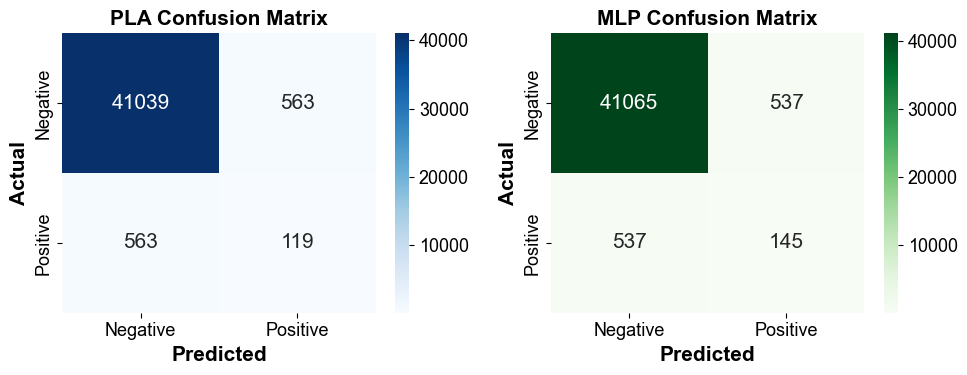

In [78]:
# ============================================
# CONFUSION MATRIX (TP FP FN TN) — PLA vs MLP
# ============================================

from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to binary format
y_test_bin = label_binarize(y_test, classes=range(num_classes))
pla_pred_bin = label_binarize(pla_pred, classes=range(num_classes))
mlp_pred_bin = label_binarize(mlp_pred, classes=range(num_classes))

# Get confusion matrices per class
cm_pla_all = multilabel_confusion_matrix(y_test_bin, pla_pred_bin)
cm_mlp_all = multilabel_confusion_matrix(y_test_bin, mlp_pred_bin)

# Sum over all classes → overall TP FP FN TN
def get_total_cm(cm_all):
    TN = cm_all[:,0,0].sum()
    FP = cm_all[:,0,1].sum()
    FN = cm_all[:,1,0].sum()
    TP = cm_all[:,1,1].sum()
    return np.array([[TN, FP],[FN, TP]])

cm_pla_total = get_total_cm(cm_pla_all)
cm_mlp_total = get_total_cm(cm_mlp_all)

# -----------------------------
# Plot as subplots
# -----------------------------
fig, axes = plt.subplots(1,2, figsize=(10,4))

labels = ["Negative","Positive"]

# PLA
sns.heatmap(cm_pla_total, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("PLA Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# MLP
sns.heatmap(cm_mlp_total, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("MLP Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [71]:
print("\nFinal Comparison")

print("PLA Accuracy:", accuracy_score(y_test, pla_pred))
print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))



Final Comparison
PLA Accuracy: 0.1744868035190616
MLP Accuracy: 0.2126099706744868


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


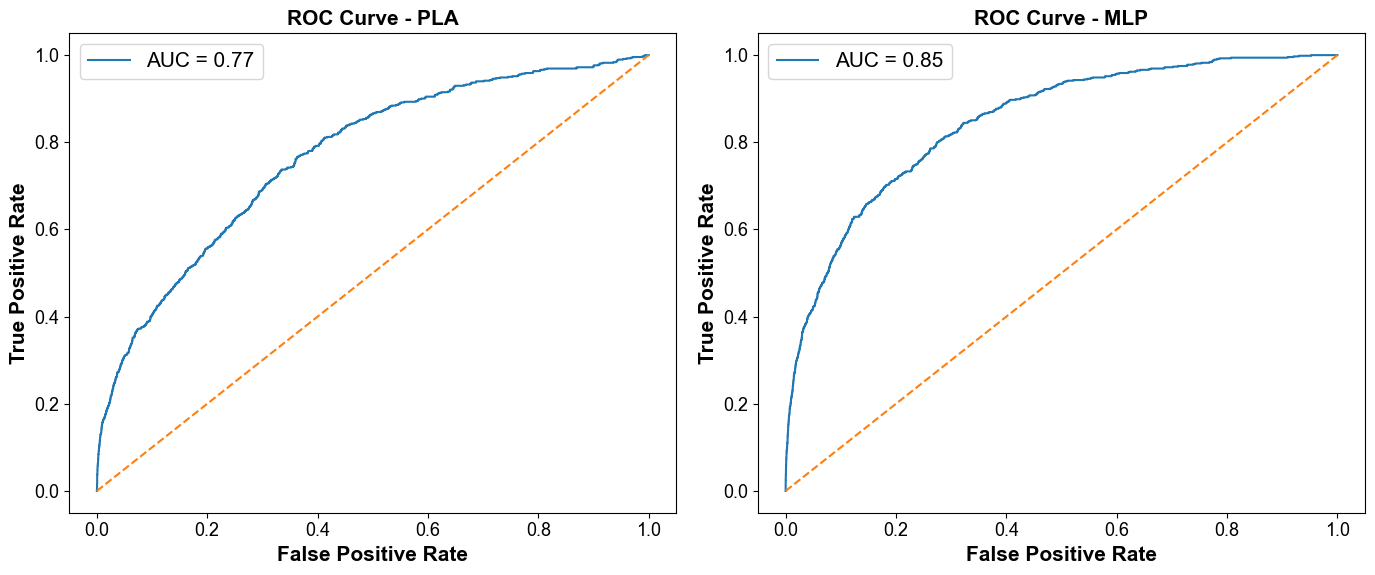

In [79]:
# ============================================
# ROC CURVES — PLA vs MLP (SUBPLOTS)
# ============================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Binarize labels (common)
# -----------------------------
y_test_bin = label_binarize(y_test, classes=range(num_classes))

# -----------------------------
# GET SCORES
# -----------------------------

# MLP → probabilities
mlp_score = mlp.predict(X_test)

# PLA → decision scores (custom model)
pla_score = pla.decision_function(X_test)

# Handle binary case
if pla_score.ndim == 1:
    pla_score = pla_score.reshape(-1, 1)

# -----------------------------
# FUNCTION TO COMPUTE ROC
# -----------------------------
def compute_micro_roc(y_true_bin, y_score):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Compute ROC
fpr_pla, tpr_pla, auc_pla = compute_micro_roc(y_test_bin, pla_score)
fpr_mlp, tpr_mlp, auc_mlp = compute_micro_roc(y_test_bin, mlp_score)

# -----------------------------
# PLOT SUBPLOTS
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---- PLA ROC ----
axes[0].plot(fpr_pla, tpr_pla, label=f"AUC = {auc_pla:.2f}")
axes[0].plot([0,1], [0,1], linestyle="--")
axes[0].set_title("ROC Curve - PLA")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# ---- MLP ROC ----
axes[1].plot(fpr_mlp, tpr_mlp, label=f"AUC = {auc_mlp:.2f}")
axes[1].plot([0,1], [0,1], linestyle="--")
axes[1].set_title("ROC Curve - MLP")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

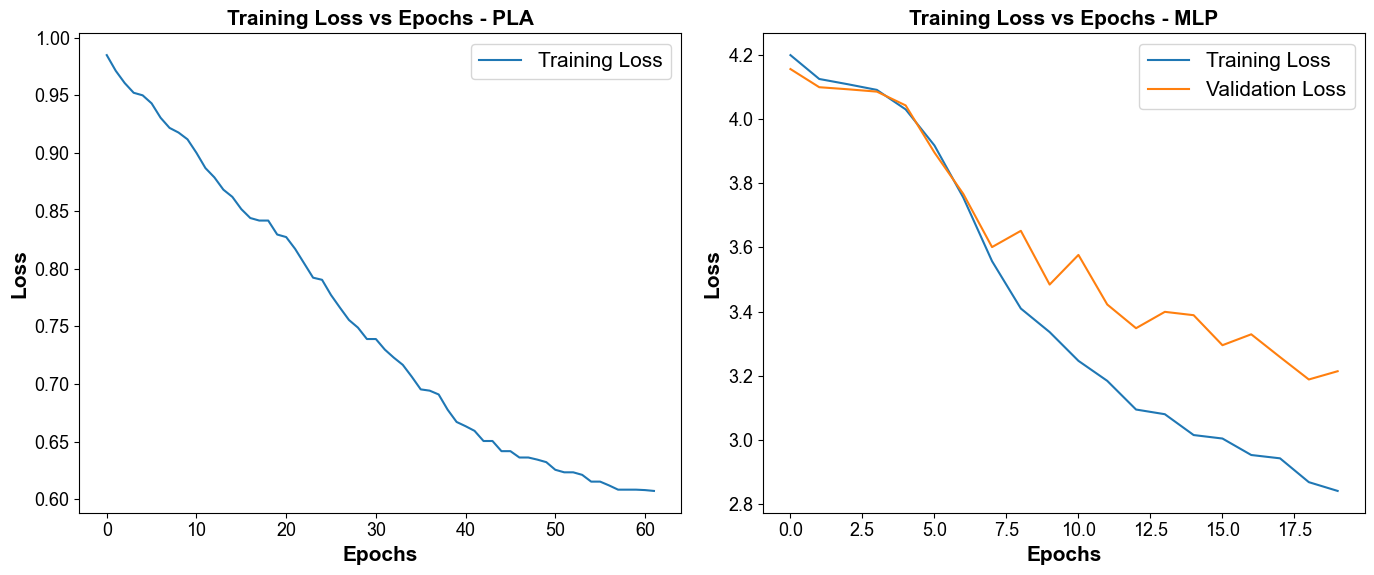

In [80]:
# ============================================
# TRAINING LOSS vs EPOCHS — PLA vs MLP
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# -----------------------------
# PLA Loss
# -----------------------------
axes[0].plot(pla.loss_history, label="Training Loss")
axes[0].set_title("Training Loss vs Epochs - PLA")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# -----------------------------
# MLP Loss
# -----------------------------
axes[1].plot(history.history['loss'], label="Training Loss")

if 'val_loss' in history.history:
    axes[1].plot(history.history['val_loss'], label="Validation Loss")

axes[1].set_title("Training Loss vs Epochs - MLP")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()